In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

In [4]:
match = pd.read_csv('matches.csv')
delivery = pd.read_csv('deliveries.csv')

In [5]:
match.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [6]:
match.shape

(756, 18)

In [7]:
delivery.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [9]:
total_score_df = (
    delivery.groupby(['match_id', 'inning'])['total_runs']
    .sum()
    .reset_index()
)
total_score_df = total_score_df[total_score_df['inning'] == 1]
total_score_df

,match_id,inning,total_runs
0,1,1,207
2,2,1,184
4,3,1,183
6,4,1,163
8,5,1,157
...,...,...,...
1518,11347,1,143
1520,11412,1,136
1522,11413,1,171
1524,11414,1,155


In [10]:
match_df = match.merge(
    total_score_df[['match_id', 'total_runs']],
    left_on='id',
    right_on='match_id'
)
match_df

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_id,total_runs
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,1,207
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2,184
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,3,183
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,4,163
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,5,157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,11347,IPL-2019,Mumbai,05-05-2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi,11347,143
752,11412,IPL-2019,Chennai,07-05-2019,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,normal,0,Mumbai Indians,0,6,AS Yadav,M. A. Chidambaram Stadium,Nigel Llong,Nitin Menon,Ian Gould,11412,136
753,11413,IPL-2019,Visakhapatnam,08-05-2019,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN,11413,171
754,11414,IPL-2019,Visakhapatnam,10-05-2019,Delhi Capitals,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,6,F du Plessis,ACA-VDCA Stadium,Sundaram Ravi,Bruce Oxenford,Chettithody Shamshuddin,11414,155


In [11]:
match_df['team1'].unique()

array(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants',
       'Delhi Capitals'], dtype=object)

In [12]:
teams = [
    'Sunrisers Hyderabad',
    'Mumbai Indians',
    'Royal Challengers Bangalore',
    'Kolkata Knight Riders',
    'Kings XI Punjab',
    'Chennai Super Kings',
    'Rajasthan Royals',
    'Delhi Capitals'
]

In [13]:
match_df.loc[:, 'team1'] = match_df['team1'].str.replace('Delhi Daredevils', 'Delhi Capitals', regex=False)
match_df.loc[:, 'team2'] = match_df['team2'].str.replace('Delhi Daredevils', 'Delhi Capitals', regex=False)
match_df.loc[:, 'team1'] = match_df['team1'].str.replace('Deccan Chargers', 'Sunrisers Hyderabad', regex=False)
match_df.loc[:, 'team2'] = match_df['team2'].str.replace('Deccan Chargers', 'Sunrisers Hyderabad', regex=False)

In [15]:
match_df = match_df[match_df['team1'].isin(teams) & match_df['team2'].isin(teams)]
match_df.shape

(641, 20)

In [16]:
match_df = match_df[match_df['dl_applied'] == 0]
match_df = match_df[['match_id', 'city', 'winner', 'total_runs']]

In [17]:
delivery_df = match_df.merge(delivery, on='match_id')
delivery_df = delivery_df[delivery_df['inning'] == 2].copy()
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder
125,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,0,0,0,0,1,0,1,NaN,NaN,NaN
126,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,0,0,0,0,0,0,0,NaN,NaN,NaN
127,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,0,0,0,0,0,0,0,NaN,NaN,NaN
128,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,0,0,0,0,2,0,2,NaN,NaN,NaN
129,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,0,0,0,0,4,0,4,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149573,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,0,0,0,0,1,0,1,NaN,NaN,NaN
149574,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,0,0,0,0,2,0,2,NaN,NaN,NaN
149575,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya
149576,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,0,0,0,0,2,0,2,NaN,NaN,NaN


In [18]:
delivery_df.loc[:, 'total_runs_y'] = pd.to_numeric(delivery_df['total_runs_y'], errors='coerce').fillna(0).astype(int)
delivery_df.loc[:, 'total_runs_x'] = pd.to_numeric(delivery_df['total_runs_x'], errors='coerce').fillna(0).astype(int)
delivery_df.loc[:, 'over'] = pd.to_numeric(delivery_df['over'], errors='coerce').fillna(0).astype(int)
delivery_df.loc[:, 'ball'] = pd.to_numeric(delivery_df['ball'], errors='coerce').fillna(0).astype(int)

In [19]:
delivery_df.loc[:, 'current_score'] = delivery_df.groupby('match_id')['total_runs_y'].transform('cumsum')

In [21]:
delivery_df.loc[:, 'runs_left'] = delivery_df['total_runs_x'] - delivery_df['current_score']
delivery_df.loc[:, 'balls_left'] = 126 - (delivery_df['over'] * 6 + delivery_df['ball'])
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,penalty_runs,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left
125,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,0,1,0,1,NaN,NaN,NaN,1,206,119
126,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,0,0,0,0,NaN,NaN,NaN,1,206,118
127,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,0,0,0,0,NaN,NaN,NaN,1,206,117
128,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,0,2,0,2,NaN,NaN,NaN,3,204,116
129,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,0,4,0,4,NaN,NaN,NaN,7,200,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149573,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,0,1,0,1,NaN,NaN,NaN,152,0,4
149574,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,0,2,0,2,NaN,NaN,NaN,154,-2,3
149575,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,0,1,0,1,SR Watson,run out,KH Pandya,155,-3,2
149576,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,0,2,0,2,NaN,NaN,NaN,157,-5,1


In [23]:
delivery_df.loc[:, 'player_dismissed_flag'] = (~delivery_df['player_dismissed'].isna()).astype(int)
delivery_df.loc[:, 'wickets_fallen'] = delivery_df.groupby(['match_id', 'inning'])['player_dismissed_flag'].transform('cumsum')
delivery_df.loc[:, 'wickets'] = 10 - delivery_df['wickets_fallen']
delivery_df.head()

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left,player_dismissed_flag,wickets_fallen,wickets
125,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,1,NaN,NaN,NaN,1,206,119,0,0,10
126,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,0,NaN,NaN,NaN,1,206,118,0,0,10
127,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,0,NaN,NaN,NaN,1,206,117,0,0,10
128,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,2,NaN,NaN,NaN,3,204,116,0,0,10
129,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,4,NaN,NaN,NaN,7,200,115,0,0,10


In [25]:
overs_completed_remaining = (120 - delivery_df['balls_left'])
delivery_df.loc[:, 'crr'] = np.where(
    overs_completed_remaining == 0,
    np.nan,
    (delivery_df['current_score'] * 6) / overs_completed_remaining
)
delivery_df.loc[:, 'rrr'] = np.where(
    delivery_df['balls_left'] == 0,
    np.nan,
    (delivery_df['runs_left'] * 6) / delivery_df['balls_left']
)

In [26]:
delivery_df.loc[:, 'result'] = np.where(delivery_df['batting_team'] == delivery_df['winner'], 1, 0).astype(int)

In [27]:
final_df = delivery_df[[
    'batting_team', 'bowling_team', 'city',
    'runs_left', 'balls_left', 'wickets',
    'total_runs_x', 'crr', 'rrr', 'result'
]].copy()

In [28]:
final_df = final_df.sample(frac=1, random_state=1).reset_index(drop=True)
final_df.sample()

,batting_team,bowling_team,city,runs_left,balls_left,wickets,total_runs_x,crr,rrr,result
22627,Royal Challengers Bangalore,Rajasthan Royals,Bangalore,116,54,6,195,7.181818,12.888889,0


In [29]:
final_df.dropna(inplace=True)
final_df = final_df[final_df['balls_left'] != 0]

In [30]:
X = final_df.iloc[:, :-1]
y = final_df.iloc[:, -1]

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [32]:
X_train

,batting_team,bowling_team,city,runs_left,balls_left,wickets,total_runs_x,crr,rrr
10917,Royal Challengers Bangalore,Mumbai Indians,Bengaluru,127,74,8,197,9.130435,10.297297
72337,Kings XI Punjab,Deccan Chargers,Kimberley,139,102,10,168,9.666667,8.176471
2159,Delhi Daredevils,Mumbai Indians,Mumbai,83,42,7,173,6.923077,11.857143
43387,Kings XI Punjab,Rajasthan Royals,Durban,186,91,8,211,5.172414,12.263736
65539,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata,82,69,8,129,5.529412,7.130435
...,...,...,...,...,...,...,...,...,...
49811,Sunrisers Hyderabad,Royal Challengers Bangalore,Bengaluru,118,50,8,222,8.914286,14.160000
20897,Chennai Super Kings,Kolkata Knight Riders,Chennai,146,117,10,147,2.000000,7.487179
21742,Kolkata Knight Riders,Mumbai Indians,East London,67,41,8,148,6.151899,9.804878
50784,Royal Challengers Bangalore,Delhi Daredevils,Sharjah,20,29,8,145,8.241758,4.137931


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [34]:
ohe_kwargs = {'sparse_output': False}
try:
    _ = OneHotEncoder(**ohe_kwargs)
except TypeError:
    ohe_kwargs = {'sparse': False}

In [35]:
trf = ColumnTransformer([
    ('trf', OneHotEncoder(drop='first', **ohe_kwargs), ['batting_team', 'bowling_team', 'city'])
], remainder='passthrough')

In [36]:
pipe = Pipeline(steps=[
    ('step1', trf),
    ('step2', LogisticRegression(solver='liblinear'))
])

In [37]:
pipe.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'city'])])),
                ('step2', LogisticRegression(solver='liblinear'))])

In [39]:
from sklearn.metrics import accuracy_score
y_pred = pipe.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Sample prediction probability (index 10):", pipe.predict_proba(X_test)[10])

Accuracy: 0.8079753311374308
Sample prediction probability (index 10): [0.80863278 0.19136722]


In [40]:
def match_summary(row):
    print("Batting Team-" + row['batting_team'] +
          " | Bowling Team-" + row['bowling_team'] +
          " | Target- " + str(row['total_runs_x']))

In [42]:
def match_progression(x_df, match_id, pipe):
    match = x_df[x_df['match_id'] == match_id].copy()
    match = match[match['ball'] == 6]
    temp_df = match[[
        'batting_team', 'bowling_team', 'city',
        'runs_left', 'balls_left', 'wickets',
        'total_runs_x', 'crr', 'rrr'
    ]].dropna().copy()
    temp_df = temp_df[temp_df['balls_left'] != 0].reset_index(drop=True)
    if temp_df.empty:
        return temp_df, None

    proba = pipe.predict_proba(temp_df)
    temp_df.loc[:, 'lose'] = np.round(proba[:, 0] * 100, 1)
    temp_df.loc[:, 'win'] = np.round(proba[:, 1] * 100, 1)
    temp_df.loc[:, 'end_of_over'] = np.arange(1, temp_df.shape[0] + 1)
    
    target = temp_df['total_runs_x'].values[0]
    runs = list(temp_df['runs_left'].values)
    new_runs = runs[:]
    runs_with_target = [target] + runs
    temp_df.loc[:, 'runs_after_over'] = np.array(runs_with_target)[:-1] - np.array(new_runs)

    wickets = list(temp_df['wickets'].values)
    new_wickets = [10] + wickets[:-1]
    temp_df.loc[:, 'wickets_in_over'] = np.array(new_wickets) - np.array(wickets)

    temp_df = temp_df[['end_of_over', 'runs_after_over', 'wickets_in_over', 'lose', 'win']]
    print("Target-", target)
    return temp_df, target

In [43]:
temp_df, target = match_progression(delivery_df, 74, pipe)
print(temp_df)

Target- 178
    end_of_over  runs_after_over  wickets_in_over  lose   win
0             1                4                0  56.4  43.6
1             2                8                0  51.2  48.8
2             3                1                0  58.0  42.0
3             4                7                1  69.6  30.4
4             5               12                0  59.6  40.4
5             6               13                0  47.3  52.7
6             7                9                0  41.4  58.6
7             8               15                0  27.6  72.4
8             9                7                0  25.4  74.6
9            10               17                0  13.9  86.1
10           11                9                1  19.3  80.7
11           12                9                0  15.9  84.1
12           13                8                0  13.7  86.3
13           14                8                0  11.7  88.3
14           15                5                1  20.5  7

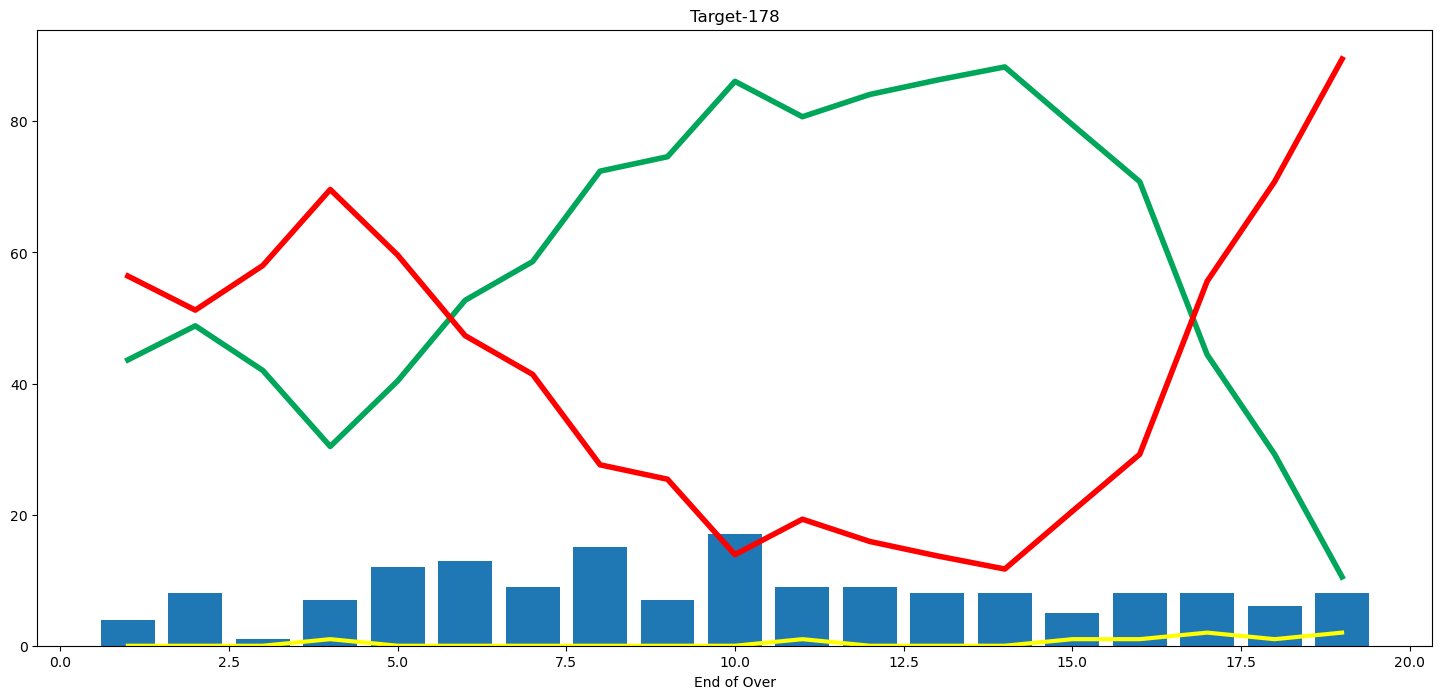

In [44]:
if temp_df is not None and not temp_df.empty:
    plt.figure(figsize=(18, 8))
    plt.plot(temp_df['end_of_over'], temp_df['wickets_in_over'], color='yellow',linewidth=3)
    plt.plot(temp_df['end_of_over'], temp_df['win'],color='#00a65a',linewidth=4)
    plt.plot(temp_df['end_of_over'], temp_df['lose'], color='red',linewidth=4)
    plt.bar(temp_df['end_of_over'], temp_df['runs_after_over'])
    plt.title('Target-' + str(target))
    plt.xlabel('End of Over')
    plt.show()

In [49]:
pickle.dump(pipe, open('pipe.pkl', 'wb'))

In [50]:
teams

['Sunrisers Hyderabad',
 'Mumbai Indians',
 'Royal Challengers Bangalore',
 'Kolkata Knight Riders',
 'Kings XI Punjab',
 'Chennai Super Kings',
 'Rajasthan Royals',
 'Delhi Capitals']

In [51]:
delivery_df['city'].unique()

array(['Hyderabad', 'Bangalore', 'Mumbai', 'Indore', 'Kolkata', 'Delhi',
       'Chandigarh', 'Jaipur', 'Chennai', 'Cape Town', 'Port Elizabeth',
       'Durban', 'Centurion', 'East London', 'Johannesburg', 'Kimberley',
       'Bloemfontein', 'Ahmedabad', 'Cuttack', 'Nagpur', 'Dharamsala',
       'Visakhapatnam', 'Pune', 'Raipur', 'Ranchi', 'Abu Dhabi',
       'Sharjah', nan, 'Mohali', 'Bengaluru'], dtype=object)